<a href="https://colab.research.google.com/github/arsenhh-byte/Machine-Learning/blob/main/weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Predict Weather Patterns in Different Locations in Africa

Khalid A. Ahmed - 667378

Arsen Ogutu - 666013

SDG 13: Climate Action

Dataset: World Weather Repository


# Documentation

### Overview

This project is designed to predict weather patterns in African countries using historical weather data. The goal is to forecast temperatures based on various factors such as location, date, humidity, wind speed, and precipitation. The project involves:

1.   Preprocessing the dataset: Filtering, cleaning, and feature engineering.
2.   Exploratory Data Analysis (EDA): Exploring temperature trends, weather conditions, and insights from various features.
3.   Modeling: Training a Random Forest Regressor model to predict temperatures.
4.   Evaluation: Using metrics like R-squared, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to assess model performance.
5.   Prediction Interface: Users can input a location and date to receive a temperature prediction.









## Dataset
The dataset used is the [Global Weather Repository](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository/data) dataset from Kaggle. It contains weather data for different locations, with the following columns:

## Columns Description
| Column Name                             | Description                                      |
|-----------------------------------------|--------------------------------------------------|
| country                                 | The country where the location is situated      |
| location_name                           | The name of the specific location                |
| latitude                                | The geographical latitude of the location        |
| longitude                               | The geographical longitude of the location       |
| timezone                                | The timezone of the location                     |
| last_updated_epoch                      | Epoch time of the last update                    |
| last_updated                            | The last updated timestamp                        |
| temperature_celsius                     | Temperature in degrees Celsius                    |
| temperature_fahrenheit                  | Temperature in degrees Fahrenheit                 |
| condition_text                          | Text description of the weather condition        |
| wind_mph                                | Wind speed in miles per hour                     |
| wind_kph                                | Wind speed in kilometers per hour                |
| wind_degree                             | Wind direction in degrees                         |
| wind_direction                          | Text description of wind direction                |
| pressure_mb                             | Atmospheric pressure in millibars                |
| pressure_in                             | Atmospheric pressure in inches                    |
| precip_mm                               | Precipitation in millimeters                      |
| precip_in                               | Precipitation in inches                           |
| humidity                                | Humidity percentage                               |
| cloud                                   | Cloud cover percentage                            |
| feels_like_celsius                      | Apparent temperature in degrees Celsius          |
| feels_like_fahrenheit                   | Apparent temperature in degrees Fahrenheit       |
| visibility_km                           | Visibility in kilometers                          |
| visibility_miles                        | Visibility in miles                               |
| uv_index                                | UV index value                                   |
| gust_mph                                | Wind gust speed in miles per hour                |
| gust_kph                                | Wind gust speed in kilometers per hour           |
| air_quality_Carbon_Monoxide            | Carbon monoxide level in air quality             |
| air_quality_Ozone                       | Ozone level in air quality                       |
| air_quality_Nitrogen_dioxide            | Nitrogen dioxide level in air quality            |
| air_quality_Sulphur_dioxide             | Sulphur dioxide level in air quality             |
| air_quality_PM2.5                       | PM2.5 level in air quality                       |
| air_quality_PM10                        | PM10 level in air quality                        |
| air_quality_us-epa-index                | US EPA air quality index                         |
| air_quality_gb-defra-index              | UK DEFRA air quality index                       |
| sunrise                                 | Time of sunrise                                  |
| sunset                                  | Time of sunset                                   |
| moonrise                                | Time of moonrise                                 |
| moonset                                 | Time of moonset                                  |
| moon_phase                              | Current phase of the moon                        |
| moon_illumination                       | Illumination percentage of the moon              |


# Key Steps in the Project

## Step 1: Import Libraris

The necessary Python libraries are imported, including:

- Scikit-learn for machine learning (Random Forest Regressor, metrics, preprocessing).
- Matplotlib and Seaborn for data visualization.
- Plotly for interactive visualizations.
- Pandas and NumPy for data manipulation.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import joblib


## Step 2: Load and Explore the Dataset

The dataset is loaded using Pandas, and basic exploration is performed:

- Shape of the dataset.
- Summary statistics.
- Temperature summary (mean, min, max temperatures).

In [ ]:
data = pd.read_csv('GlobalWeatherRepository.csv')

In [ ]:
data.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


The dataset consits of 32,022 rows and 41 columns

In [ ]:
print(f'Shape of the Dataset is: {data.shape}')


Shape of the Dataset is: (32022, 41)


In [ ]:
print(data.describe())


           latitude     longitude  last_updated_epoch  temperature_celsius  \
count  32022.000000  32022.000000        3.202200e+04         32022.000000   
mean      19.137662     22.055291        1.722969e+09            25.515783   
std       24.486636     65.815951        4.182592e+06             7.251554   
min      -41.300000   -175.200000        1.715849e+09           -10.400000   
25%        3.750000     -6.840000        1.719321e+09            21.825000   
50%       17.250000     23.320000        1.723032e+09            26.400000   
75%       40.400000     50.580000        1.726571e+09            29.600000   
max       64.150000    179.220000        1.730107e+09            49.200000   

       temperature_fahrenheit      wind_mph      wind_kph   wind_degree  \
count            32022.000000  32022.000000  32022.000000  32022.000000   
mean                77.929920      8.525167     13.723871    175.703173   
std                 13.052914     11.535227     18.564222    100.494244 

In [ ]:
# Summary statistics for temperature(Average, Maximum, and Minimum Temperatures)
temp_summary = data['temperature_celsius'].describe()
temp_summary

,temperature_celsius
count,32022.000000
mean,25.515783
std,7.251554
min,-10.400000
25%,21.825000
50%,26.400000
75%,29.600000
max,49.200000


## Step 3: Data Preprocessing
We filtered the dataset to include only rows where the timezone starts with "Africa/", ensuring it contains data for African countries.

In [ ]:
# Filter rows where 'timezone' starts with 'Africa/'
data = data[data['timezone'].str.startswith('Africa/')]

# Reset the index of the resulting DataFrame
data.reset_index(drop=True, inplace=True)

# Display the resulting DataFrame
print(data)

# Save the filtered data to a new CSV
data.to_csv('Africa_WeatherData.csv', index=False)


           country location_name  latitude  longitude              timezone  \
0          Algeria       Algiers   36.7600     3.0500        Africa/Algiers   
1           Angola        Luanda   -8.8400    13.2300         Africa/Luanda   
2            Benin    Porto-Novo    6.4800     2.6200     Africa/Porto-Novo   
3         Botswana      Gaborone  -24.6500    25.9100       Africa/Gaborone   
4     Burkina Faso   Ouagadougou   12.3700    -1.5200    Africa/Ouagadougou   
...            ...           ...       ...        ...                   ...   
7390      Tanzania        Dodoma   -6.1833    35.7500  Africa/Dar_es_Salaam   
7391       Tunisia         Tunis   36.8028    10.1797          Africa/Tunis   
7392        Uganda       Kampala    0.3156    32.5656        Africa/Kampala   
7393        Zambia        Lusaka  -15.4167    28.2833         Africa/Lusaka   
7394      Zimbabwe        Harare  -17.8178    31.0447         Africa/Harare   

      last_updated_epoch      last_updated  tempera

In [ ]:
print(data.shape)

(7395, 41)


### Observation

After preprocessing and remaining with data from the Africa continent their is **7395** rows and **41** columns

## Step 4: Data Cleaning

The dataset is cleaned by checking for:

- Missing values.
- Duplicate rows.
- Numeric vs categorical columns.

In [ ]:
# Check missing values
missing_values = data.isnull().sum().sum()

if missing_values > 0:
    print(f"Missing values are present. Total missing values: {missing_values}\n")
else:
    print(f"No missing values are present in the Dataset.\n")

print(data.isnull().sum())


No missing values are present in the Dataset.

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
a

In [ ]:
# Check duplicates
# print(data.duplicated().any())

duplicates_count = data.duplicated().sum()

if data.duplicated().any():
    print(f"Duplicates are present. Total duplicate rows: {duplicates_count}")
else:
    print(f"No duplicates are present in the Dataset.")


No duplicates are present in the Dataset.


In [ ]:
# Count numeric columns
numeric_columns_count = data.select_dtypes(include='number').shape[1]
# Get numeric column names
numeric_columns_names = data.select_dtypes(include='number').columns.tolist()

# Count categorical columns
categorical_columns_count = data.select_dtypes(include='object').shape[1]
# Get categorical column names
categorical_columns_names = data.select_dtypes(include='object').columns.tolist()

print(f'Number of numeric columns: {numeric_columns_count}')
print(f'Numeric columns: {numeric_columns_names}')
print("\n")
print(f'Number of categorical columns: {categorical_columns_count}')
print(f'Categorical columns: {categorical_columns_names}')


Number of numeric columns: 30
Numeric columns: ['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination']


Number of categorical columns: 11
Categorical columns: ['country', 'location_name', 'timezone', 'last_updated', 'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase']


### Observations

There are no missing values in this dataset.

There are no duplicate values in this dataset.

There are **30** numeric columns and **11** categorical columns in this dataset.

## Step 5: Exploratory Data Analysis (EDA)

Key insights are drawn from the dataset by examining various features:

- Temperature: Max/Min temperature by location.
- Humidity: Highest average humidity by month.
- Wind Speed: Highest recorded wind speed.
- Moon Phase: Locations with a "Full Moon".
- Date: Range of the last_updated timestamp.






### Standardize Country Names and Displaying Unique Values
### Taking Insights about the country and location name column

In [ ]:
# Show the unique values
num_unique_countries = data['country'].nunique()
unique_countries = data['country'].unique()
print(f'Number of unique countries are: {num_unique_countries}')
print(f'There are {unique_countries} unique values in the country column.')


Number of unique countries are: 47
There are ['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Congo' 'Democratic Republic of Congo'
 'Djibouti' 'Egypt' 'Equatorial Guinea' 'Eritrea' 'Swaziland' 'Ethiopia'
 'Gabon' 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Kenya' 'Lesotho'
 'Liberia' 'Malawi' 'Mali' 'Mauritania' 'Morocco' 'Mozambique' 'Namibia'
 'Niger' 'Nigeria' 'Rwanda' 'Senegal' 'Sierra Leone' 'Somalia'
 'South Africa' 'Sudan' 'Tanzania' 'Tunisia' 'Uganda' 'Zambia' 'Zimbabwe'
 'Libya' 'Togo' 'Marrocos'] unique values in the country column.


In [ ]:
# Check the minimum and maximum values of the country column
min_country, max_country = data['country'].min(), data['country'].max()
print(f"The 'country' which occurs minimum in this dataset is: {min_country}")
print(f"The 'country' which occurs maximum in this dataset is: {max_country}")


The 'country' which occurs minimum in this dataset is: Algeria
The 'country' which occurs maximum in this dataset is: Zimbabwe


In [ ]:
# Show the number of unique values
num_unique_location_name = data['location_name'].nunique()
print(f'There are {num_unique_location_name} unique values in the location_name column.')
# Check the minimum and maximum values of the location_name column
min_location_name, max_location_name = data['location_name'].min(), data['location_name'].max()
print(f"The 'Location_name' which occurs minimum in this dataset is: {min_location_name}")
print(f"The 'Location_name' which occurs maximum in this dataset is: {max_location_name}")

There are 53 unique values in the location_name column.
The 'Location_name' which occurs minimum in this dataset is: Abuja
The 'Location_name' which occurs maximum in this dataset is: Yaounde


In [ ]:
# Count unique combinations of country and location_name
country_location_count = data.groupby(['country', 'location_name']).size().reset_index(name='count')

# Get the number of unique countries along with their location names
unique_countries = country_location_count['country'].nunique()

print(f"Total number of unique countries along with their location names present in the dataset are: {unique_countries}")


Total number of unique countries along with their location names present in the dataset are: 47


### Observations

There are **47** unique countries in this dataset from Africa.

The 'country' that occurs the minimum number of times is **Algeria**.

The 'country' that occurs the maximum number of times is **Zimbabwe**.

There are **53** unique values in the location_name column.

The 'Location_name' that occurs the minimum number of times is **Abuja**.

The 'Location_name' that occurs the maximum number of times is **Yaounde**.

Total number of unique countries along with their location names present in the dataset are **47**



### Taking Insights from Temperature Celsius

In [ ]:
# Get the country and location with the highest temperature in Celsius
highest_temp_celsius = data.loc[data['temperature_celsius'].idxmax(), ['country', 'location_name', 'temperature_celsius']]
print("Country and Location with the Highest Temperature in Celsius:")
print(highest_temp_celsius)

# Print the overall max temperatures countries and location names
print(f"\nMaximum Temperature in Celsius: {highest_temp_celsius['temperature_celsius']}")


Country and Location with the Highest Temperature in Celsius:
country                Djibouti
location_name          Djibouti
temperature_celsius        47.1
Name: 2521, dtype: object

Maximum Temperature in Celsius: 47.1


In [ ]:
# Get the country and location with the lowest temperature in Celsius
lowest_temp_celsius = data.loc[data['temperature_celsius'].idxmin(), ['country', 'location_name', 'temperature_celsius']]
print("\nCountry and Location with the Lowest Temperature in Celsius:")
print(lowest_temp_celsius)

# Print the overall min temperatures countries and location names
print(f"\nMinimum Temperature in Celsius: {lowest_temp_celsius['temperature_celsius']}")



Country and Location with the Lowest Temperature in Celsius:
country                Lesotho
location_name           Maseru
temperature_celsius        3.4
Name: 922, dtype: object

Minimum Temperature in Celsius: 3.4


### Observations

Country with the highest temperature in Celsius is **Djibouti**.

The highest temperature in Celsius is **47.1**.

Country with the Lowest Temperature in Celsius is **Lesotho** and its location is **Maseru**.

The lowesr temperature in Celsius is **3.4**.

### Taking Insights from Latitude and Longitude Column

In [ ]:
# Find the country and location with the highest latitude
highest_latitude = data.loc[data['latitude'].idxmax(), ['country', 'location_name', 'latitude']]
print("Country and Location with the Highest Latitude:")
print(highest_latitude)

# Find the country and location with the highest longitude
highest_longitude = data.loc[data['longitude'].idxmax(), ['country', 'location_name', 'longitude']]
print("\nCountry and Location with the Highest Longitude:")
print(highest_longitude)


Country and Location with the Highest Latitude:
country          Tunisia
location_name      Tunis
latitude         36.8028
Name: 6266, dtype: object

Country and Location with the Highest Longitude:
country            Somalia
location_name    Mogadishu
longitude            45.37
Name: 36, dtype: object


In [ ]:
# Find the country and location with the lowest latitude
lowest_latitude = data.loc[data['latitude'].idxmin(), ['country', 'location_name', 'latitude']]
print("\nCountry and Location with the Lowest Latitude:")
print(lowest_latitude)
# Find the country and location with the lowest longitude
lowest_longitude = data.loc[data['longitude'].idxmin(), ['country', 'location_name', 'longitude']]
print("\nCountry and Location with the Lowest Longitude:")
print(lowest_longitude)



Country and Location with the Lowest Latitude:
country          Lesotho
location_name     Maseru
latitude          -29.32
Name: 23, dtype: object

Country and Location with the Lowest Longitude:
country          Senegal
location_name      Dakar
longitude         -17.44
Name: 34, dtype: object


### Observations

Country and Location with the Highest Latitude:
*   country: **Tunisia**
*   location_name: **Tunis**

The highest latitude is **36.8028**

Country and Location with the Highest Longitude:
* country: **Somalia**
* location_name: **Mogadishu**

The highest longitude is **45.37**

Country and Location with the Lowest Latitude:
* country: **Lesotho**
* location_name: **Maseru**

The lowest latitude is **-29.32**

Country and Location with the Lowest Longitude:
* country: **Senegal**
* location_name: **Dakar**

The lowest longitude is **-17.44**


### Taking Insights from Humidity Column

In [ ]:
# Get the number of month with highest humidity
data['month'] = pd.to_datetime(data['last_updated']).dt.month
highest_avg_humidity_month = data.groupby('month')['humidity'].mean().idxmax()
print("The Number of Month with highest humidity are: ", highest_avg_humidity_month)


The Number of Month with highest humidity are:  10


In [ ]:
# Which month has the lowest average temperature
lowest_avg_temp_month = data.groupby('month')['temperature_celsius'].mean().idxmin()
print(f"Number of Month when average temperature is lowest are: {lowest_avg_temp_month}")

Number of Month when average temperature is lowest are: 10


### Observations

The Number of Month with highest humidity are:  **10**

Number of Month when average temperature is lowest are: **10**

### Taking Insights from wind kph Column

In [ ]:
# location has the highest recorded wind speed
highest_wind_speed_location = data.loc[data['wind_kph'].idxmax(), 'location_name']
highest_wind_speed_value = data['wind_kph'].max()
print(f"Location with the highest wind speed is: {highest_wind_speed_location} ({highest_wind_speed_value:.2f} kph)")

Location with the highest wind speed is: Bujumbura (2963.20 kph)


### Observation

Location with the highest wind speed is: **Bujumbura** with speed of **2963.20 kph**

### Taking Insights from moon phase Column

In [ ]:
# Check that how many locations have a moon phase listed as "Full Moon"
full_moon_count = data[data['moon_phase'] == 'Full Moon'].shape[0]
print(f"Locations with Full Moon: {full_moon_count}")

Locations with Full Moon: 268


### Observation

Locations with Full Moon: **268**

### Taking Insights from Last Updated Column

In [ ]:
# Convert date columns to datetime
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')
data['sunrise'] = pd.to_datetime(data['sunrise'], errors='coerce')
data['sunset'] = pd.to_datetime(data['sunset'], errors='coerce')
data['moonrise'] = pd.to_datetime(data['moonrise'], errors='coerce')
data['moonset'] = pd.to_datetime(data['moonset'], errors='coerce')

# Display the range of last updated dates
print("\nRange of last updated dates:", data['last_updated'].min(), "to", data['last_updated'].max())
earliest_update = data['last_updated'].min()
latest_update = data['last_updated'].max()
print(f"The Earliest Updated time is: {earliest_update}")
print(f"The Latest Updated time is: {latest_update} \n")


<ipython-input-24-ffd25d1a605e>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['sunrise'] = pd.to_datetime(data['sunrise'], errors='coerce')
<ipython-input-24-ffd25d1a605e>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['sunset'] = pd.to_datetime(data['sunset'], errors='coerce')
<ipython-input-24-ffd25d1a605e>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['moonrise'] = pd.to_datetime(data['moonrise'], errors='coerce')
<ipython-input-24-ffd25d1a605e>:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `da


Range of last updated dates: 2024-05-16 08:45:00 to 2024-10-28 12:15:00
The Earliest Updated time is: 2024-05-16 08:45:00
The Latest Updated time is: 2024-10-28 12:15:00 



In [ ]:
# How many records were last updated in 2024
last_updated_2024_count = data[data['last_updated'].dt.year == 2024].shape[0]
print(f"Records last updated in 2024: {last_updated_2024_count}")

Records last updated in 2024: 7395


### Observations

Range of last updated dates: **2024-05-16 08:45:00** to **2024-10-28 12:15:00**

The Earliest Updated time is:  **2024-05-16 08:45:00**

The Latest Updated time is:  **2024-10-28 12:15:00**

Records last updated in 2024: **7395**

## Step 6: Data Visualization

Several visualizations are created to better understand the data:

- Temperature change over time for specific locations (e.g., Nairobi).
- Temperature map of African countries.
- Temperature distribution using histograms.
- Average temperature by country using bar charts.

### Temperature Change Over Time for Nairobi

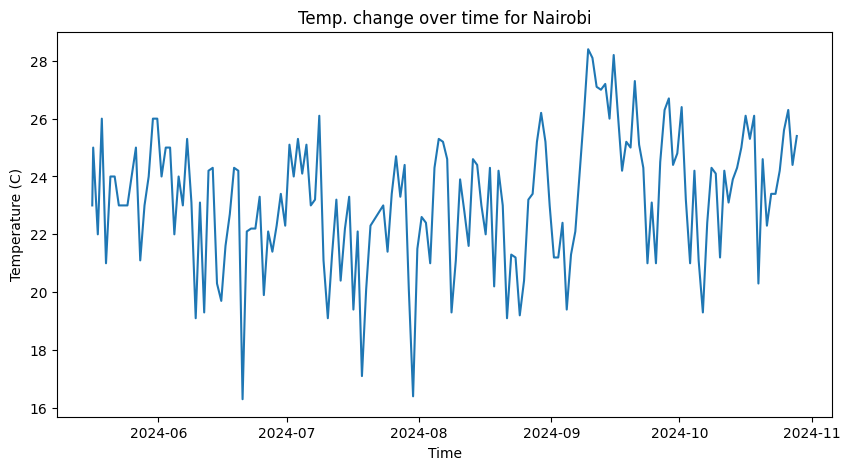

In [ ]:
location_data = data[data['location_name'] == 'Nairobi']

plt.figure(figsize=(10,5))
sns.lineplot(x='last_updated', y='temperature_celsius', data=location_data)
plt.title('Temp. change over time for Nairobi')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.show()

### Temperature Map

In [ ]:
mapbox_plot = px.scatter_mapbox(data, lat='latitude', lon='longitude', hover_name='location_name', color='temperature_celsius', title='Temperature Map')
mapbox_plot.update_layout(mapbox_style='open-street-map', mapbox=dict(zoom=1.5, center=dict(lat=0, lon=20)))
mapbox_plot.show()

### Average Temperature by Country

In [ ]:
bar_chart = px.bar(data, x='country', y='temperature_celsius', title='Average Temperature by Country')
bar_chart.show()

### Temperature Distribution

In [ ]:
histogram = px.histogram(data, x='temperature_celsius', nbins=20, title='Temperature Distribution')
histogram.show()

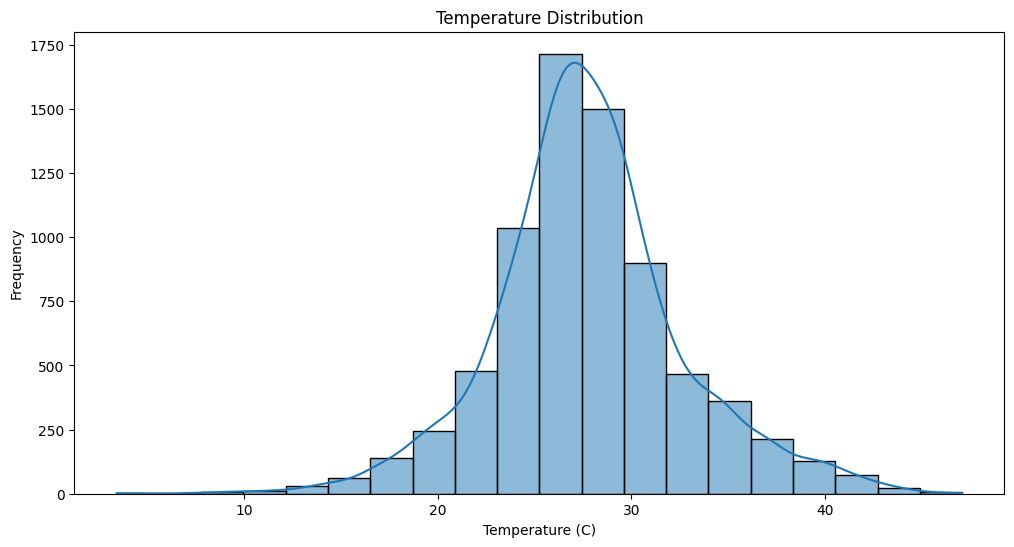

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(data['temperature_celsius'], bins=20,kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.show()

### Calendar Heatmap

In [ ]:
calendar_heatmap = px.density_heatmap(data, x='last_updated', y='location_name', z='temperature_celsius', title='Calendar Heatmap')
calendar_heatmap.show()

### Common Weather Conditions

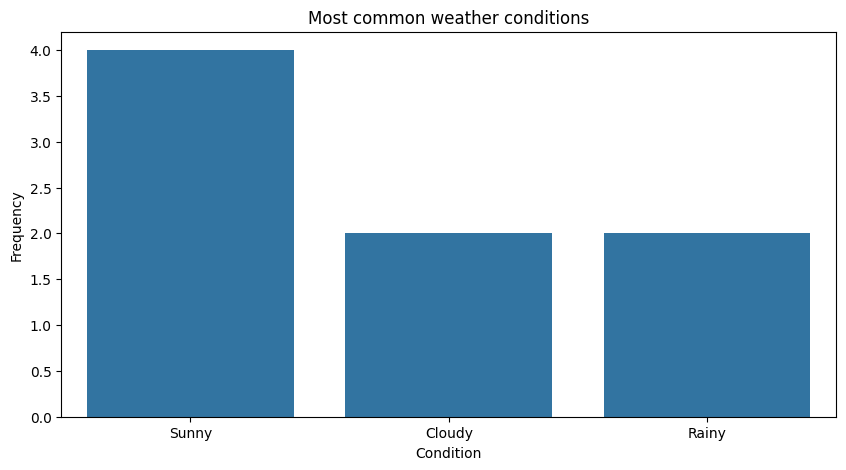

In [ ]:
weather_condition_data=['Sunny', 'Cloudy', 'Rainy', 'Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Sunny']
weather_condition_count = pd.Series(weather_condition_data).value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=weather_condition_count.index, y=weather_condition_count.values)
plt.title('Most common weather conditions')
plt.xlabel('Condition')
plt.ylabel('Frequency')
plt.show()

### Sunrise/Sunset vs Temperature

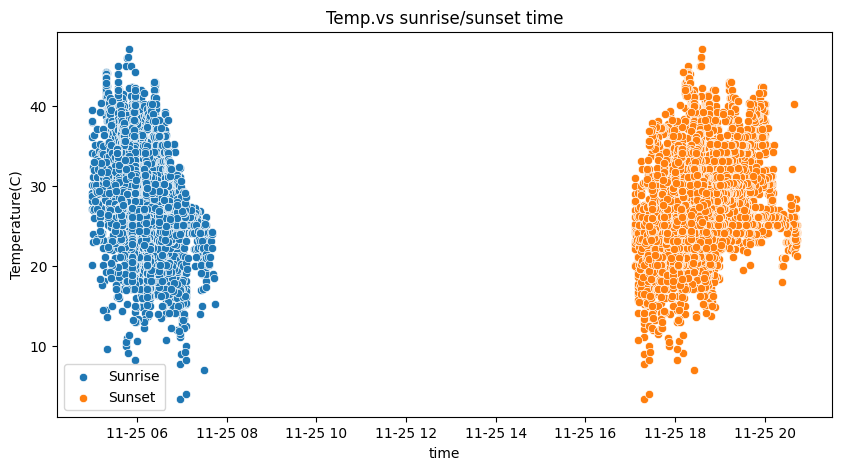

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data['sunrise'], y=data['temperature_celsius'], label='Sunrise')
sns.scatterplot(x=data['sunset'], y=data['temperature_celsius'], label='Sunset')
plt.title('Temp.vs sunrise/sunset time')
plt.xlabel('time')
plt.ylabel('Temperature(C)')
plt.legend()
plt.show()

### Average Temperature by Moon Phase

Average Temperature by Moon Phase:
 moon_phase
First Quarter      27.681221
Full Moon          27.964552
Last Quarter       27.805926
New Moon           27.643750
Waning Crescent    27.703939
Waning Gibbous     27.688881
Waxing Crescent    27.626807
Waxing Gibbous     28.131564
Name: temperature_celsius, dtype: float64


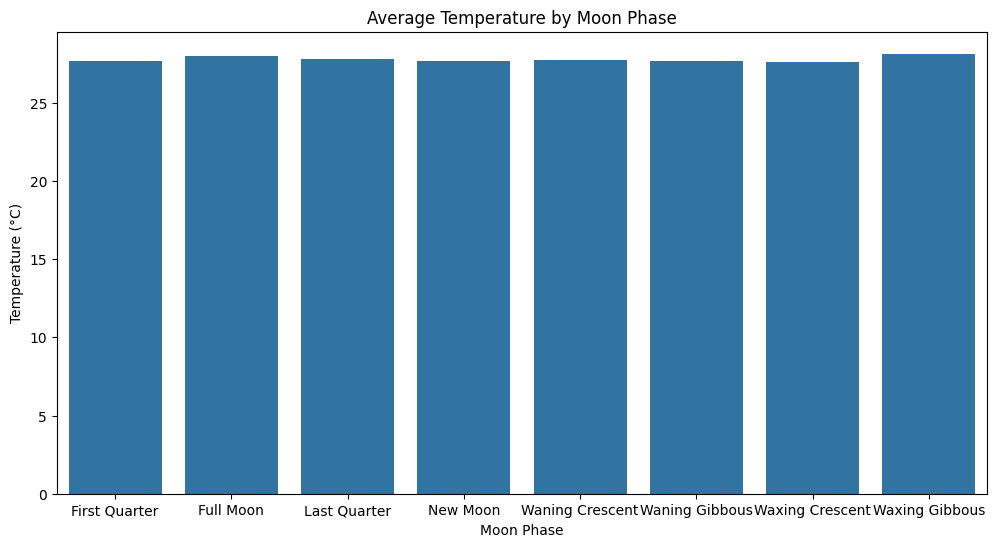

In [ ]:
# Moon phases and calculate average temperature
moon_temp_avg = data.groupby('moon_phase')['temperature_celsius'].mean()
print("Average Temperature by Moon Phase:\n", moon_temp_avg)

# Bar plot for average temperature by moon phase
plt.figure(figsize=(12, 6))
sns.barplot(x=moon_temp_avg.index, y=moon_temp_avg.values)
plt.title('Average Temperature by Moon Phase')
plt.ylabel('Temperature (°C)')
plt.xlabel('Moon Phase')
plt.show()

### Observation

**Average Temperature by Country**
- This bar chart displays the average temperature across different countries. It show a consistent pattern, with some countries experiencing notably higher average temperatures.
- Sudan stands out with a significantly higher average temperature compared to other countries.
- Most countries fall within a moderate average temperature range, suggesting a general climatic consistency.

**Temperature Distribution (Histogram)**
- The histogram illustrates the distribution of temperatures, showing the frequency of temperature occurrences across a defined range.
- The majority of temperature values fall within the range of 25–30°C, indicating that this range is the most common.
- Very few occurrences of extreme low, below 10°C or high, above 40°C temperatures.

**Temperature Distribution (With KDE)**
- The distribution plot is similar to the histogram but includes a kernel density estimate (KDE) to smooth the data distribution.
- A clear bell-shaped curve indicates that temperatures are normally distributed, peaking around 26–28°C.
- KDE provides a better understanding of temperature trends compared to the histogram alone.

**Calendar Heatmap**
- The heatmap shows temperature data over time, with intensity indicating cumulative temperature levels.
- Temperature values are highest in mid-year months, likely reflecting seasonal variations.
- Certain locations consistently exhibit higher cumulative temperature levels, suggesting regional differences.

Most Common Weather Conditions
- The bar chart represents the frequency of different weather conditions (Sunny, Cloudy, Rainy).
- “Sunny” weather is the most frequent, occurring more than “Cloudy” and “Rainy” conditions.
- Similar frequencies for “Cloudy” and “Rainy” weather conditions suggest a balanced distribution between these two.

**Temperature vs Sunrise/Sunset Times**
- The scatter plot compares temperature to sunrise and sunset times.
- Temperature during sunset shows a higher concentration of variability.
- The relationship between sunrise/sunset and temperature seems more scattered, indicating no direct correlation.

**Average Temperature by Moon Phase**
- This bar chart explores the relationship between moon phases and average temperature.
- Temperatures remain relatively consistent across different moon phases.
- No significant variations suggest that moon phases have minimal to no effect on temperature.


## Step 7: Model Training and Saving

A Random Forest Regressor model is used to predict temperatures based on various features:



1.   Feature Engineering: New columns like year, month, and day are extracted from the last_updated column.
2.   Categorical Feature Encoding: One-Hot Encoding is applied to categorical features (country, location_name, condition_text).
3.   Model Training: The dataset is split into training and testing sets, and the model is trained using a pipeline.
4.   The trained model is saved to disk for later use.






### Dropping unnecessarry columns

In [ ]:
# Droping the columns that are not useful for prediction
data = data.drop(columns=['latitude', 'longitude', 'last_updated_epoch', 'temperature_fahrenheit', 'wind_mph',
                          'wind_direction', 'pressure_in', 'precip_in', 'feels_like_celsius', 'feels_like_fahrenheit',
                          'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
                          'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5',
                          'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination',
                          'timezone', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'month', 'wind_degree',
                          'cloud', 'pressure_mb'])

print(data.shape)

# Columns left are:
# ['country', 'location_name', 'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph', 'precip_mm', 'humidity']


(7395, 8)


**R-squared (R²)**: Measures the proportion of the variance in the target variable that is explained by the model. Higher R² values (closer to 1) indicate a better fit.

**Mean Squared Error (MSE)**: The average squared difference between the predicted and actual values. Lower MSE indicates better accuracy.

**Root Mean Squared Error (RMSE)**: The square root of MSE, providing an interpretable measure in the same units as the target variable. Lower RMSE means better accuracy.

### Date Conversion

In [ ]:
# Convert the 'last_updated' column to datetime format
data['last_updated'] = pd.to_datetime(data['last_updated'], format='%m/%d/%Y %I:%M:%S %p')

### Feature Engineering

In [ ]:
# Extracting date-related features
data['year'] = data['last_updated'].dt.year
data['month'] = data['last_updated'].dt.month
data['day'] = data['last_updated'].dt.day
# data['day_of_week'] = data['last_updated'].dt.dayofweek  # Monday=0, Sunday=6

### Categorical Features

In [ ]:
# Identify categorical columns
categorical_columns = ['location_name', 'country', 'condition_text']

# Apply One-Hot Encoding to categorical columns
X = data.drop(columns=['temperature_celsius', 'last_updated']) # Features
y = data[['temperature_celsius']]  # Targets


### Preprocessing

In [ ]:
# Creating a column transformer for preprocessing the categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)  # One-hot encode categorical columns
    ],
    remainder='passthrough'  # Keep other columns which are numerical unchanged
)

# Define the model pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

### Spliting data into training and testing sets

In [ ]:
# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training

In [ ]:
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.10/dist-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['location_name', 'country',
                                                   'condition_text'])])),
                ('model', RandomForestRegressor(random_state=42))])

### Save Model

In [ ]:
# Save the trained model to disk
joblib.dump(pipeline, 'weather_model.pkl')

print("Model saved successfully!")

Model saved successfully!


## Step 8: Model Prediction and Evaluation

- Model Evaluation: The model's performance is evaluated using R-squared, MSE, and RMSE metrics.

In [ ]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



### Model Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")
print(f'Root Mean Squared Error (RMSE): {rmse}')

R-squared: 0.8857272253915235
Mean Squared Error: 2.6528074408384046
Root Mean Squared Error (RMSE): 1.6287441299474894


### Visualization

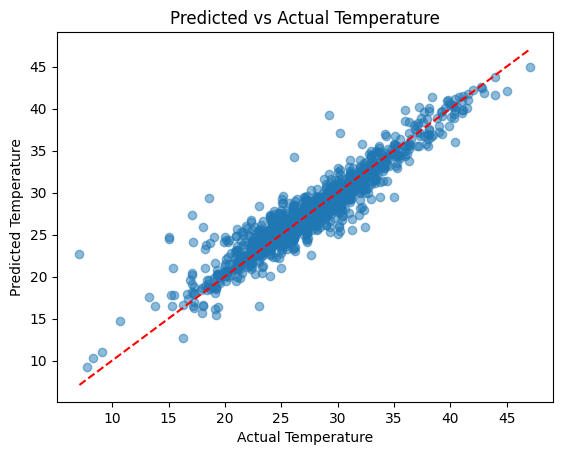

In [ ]:
# Visualize predicted vs actual values
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Predicted vs Actual Temperature')
plt.show()

### Function for Input Preprocessing

In [ ]:
# csv with african data only to used for visualising temperature change over time for specific locations.
africa_data = pd.read_csv('Africa_WeatherData.csv')
africa_data['last_updated'] = pd.to_datetime(africa_data['last_updated'], errors='coerce')


In [ ]:
# Calculate the average values for wind_kph, humidity, and precip_mm
avg_humidity = data['humidity'].mean()
avg_wind_kph = data['wind_kph'].mean()
avg_precip_mm = data['precip_mm'].mean()

print(f"Average Humidity: {avg_humidity:.2f}")
print(f"Average Wind Speed (kph): {avg_wind_kph:.2f}")
print(f"Average Precipitation (mm): {avg_precip_mm:.2f}")


Average Humidity: 53.85
Average Wind Speed (kph): 14.63
Average Precipitation (mm): 0.16


A function to predict temperatures based on user input.
Users can input a location and date, and the system will return the predicted temperature for that location.

In [ ]:
def predict_weather(location_name, date_str):
    # Convert the date string to a datetime object
    date = datetime.strptime(date_str, '%Y-%m-%d')

    # Create a DataFrame with the input location and date
    # Only provide location and date-related features
    input_data = pd.DataFrame({
        'country': ['Unknown'],
        'location_name': [location_name],
        'condition_text': ['Unknown'],
        'year': [date.year],
        'month': [date.month],
        'day': [date.day],
        'humidity': [avg_humidity],
        'wind_kph': [avg_wind_kph],
        'precip_mm': [avg_precip_mm]
    })


    # Make the prediction using the trained model pipeline
    predicted_temp = pipeline.predict(input_data)

    return predicted_temp[0]

### Temperature Prediction

In [ ]:
# List of available locations
location_names = data['location_name'].unique()
print(f'There are {location_names} unique values in the location name column.')


There are ['Algiers' 'Luanda' 'Porto-Novo' 'Gaborone' 'Ouagadougou' 'Bujumbura'
 'Yaounde' 'Bangui' "N'djamena" 'Brazzaville' 'Kinshasa' 'Djibouti'
 'Cairo' 'Malabo' 'Asmara' 'Mbabane' 'Addis Ababa' 'Libreville' 'Banjul'
 'Accra' 'Conakry' 'Bissau' 'Nairobi' 'Maseru' 'Monrovia' 'Lilongwe'
 'Bamako' 'Nouakchott' 'Rabat' 'Maputo' 'Windhoek' 'Niamey' 'Abuja'
 'Kigali' 'Dakar' 'Freetown' 'Mogadishu' 'Pretoria' 'Juba' 'Khartoum'
 'Dodoma' 'Tunis' 'Kampala' 'Lusaka' 'Harare' 'Bafoussam' 'Ngaoundere'
 'Mombasa' 'Douala' 'Addis Abeba' 'Tripoli' 'Lome' 'Morocco City'] unique values in the location name column.




Enter location (or 'q' to quit): nairobi
Enter date (YYYY-MM-DD): 2024-11-26


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning:

Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros



Predicted temperature for Nairobi on 2024-11-26:
Temperature: 27.18°C 



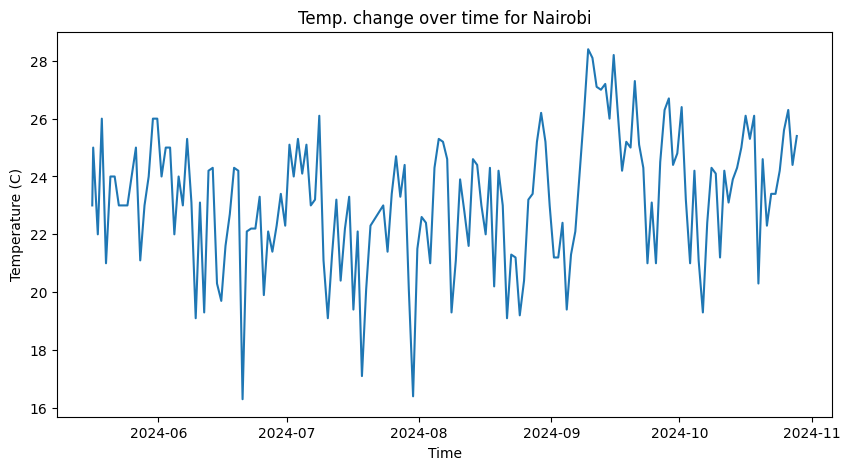

<Figure size 640x480 with 0 Axes>



Enter location (or 'q' to quit): q
Exiting the program.


In [ ]:
while True:
    location = input("\n\nEnter location (or 'q' to quit): ").strip()

    # Check if the user wants to quit
    if location.lower() == 'q':
        print("Exiting the program.")
        break

    # Check if the entered location is in the list of accepted locations
    if location.title() not in location_names:
        print(f"Sorry, {location} is not available. Please try again.\n")
        continue

    # Get user input for date
    date = input("Enter date (YYYY-MM-DD): ").strip()

    # Get the predicted temperature
    predicted_temp = predict_weather(location, date)

    # Print the predicted temperature
    print(f"Predicted temperature for {location.title()} on {date}:")
    print(f"Temperature: {predicted_temp:.2f}°C \n")

    location_data = africa_data[africa_data['location_name'] == location.title()]

    plt.figure(figsize=(10,5))
    sns.lineplot(x='last_updated', y='temperature_celsius', data=location_data)
    plt.title(f'Temp. change over time for {location.title()}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (C)')
    # plt.show()
    plt.draw()  # Ensure the plot is drawn immediately
    plt.pause(1)  # Give time for the plot to render
    plt.clf()  # Clear the figure after rendering so that it doesn't accumulate

    # Wait for the plot window to be closed, but do not block the input prompt
    plt.ioff()  # Turn off interactive mode so the input prompt works again
    plt.show()

    # Return to interactive mode for the next loop iteration
    plt.ion()



### Observation

**Feature Engineering and Data Preparation**
- We removed columns that we deemed irrelevant for the prediction of temperature such as air quality, visibility, time-based features like sunrise/sunset, etc.
- Remaining features are
  - Categorical: country, location_name, condition_text
  - Numerical: humidity, wind_kph, precip_mm, year, month, day
  - The target variable is temperature_celsius.
- Date conversion: the last_updated column is converted to a datetime format, and new features like the year, month, and day are extracted.

**Model Development**
- The categorical columns which are location_name, country and condition_text are one-hot encoded. This is necessary as machine learning models typically require numerical input, and one-hot encoding transforms categorical data into a binary matrix.
- We used Random Forest Regressor, which is a robust model for regression tasks. Random forests typically perform well with diverse data and are less prone to overfitting, thus making it suitable for this kind of weather prediction task. Our model uses 100 estimators (n_estimators=100), and a random seed ensures reproducibility.

**Evaluation Metrics**
- R-squared: The model has an R-squared value of 0.886, which is quite high. This indicates that the model explains about 88.6% of the variance in the temperature data, suggesting good predictive power.
- Mean Squared Error (MSE): The MSE value is 2.65, indicating that, on average, the model's predictions are off by approximately 2.65 degrees Celsius squared.
- Root Mean Squared Error (RMSE): The RMSE value is 1.63 degrees Celsius, which is a more interpretable measure of error. This means that, on average, the model's predictions are off by 1.63°C.

**Temperature Prediction**
- The predict_weather function allows users to input a location and a date, and it uses the trained model to predict the temperature for that location on the given date. This function creates a feature vector based on the given location and date, along with average values for humidity, wind speed, and precipitation.
- The code supports interactive input for location and date, and it also checks if the location exists in the training dataset (location_names), ensuring valid inputs.

**Visualizing Temperature Trends**

- **Predicted vs Actual Temperature**
  - The scatter plot compares actual temperature measurements with model-predicted temperatures.
  - The close alignment of points along the red line indicates that the model predicts temperature accurately.
  - Deviations from the line are minimal, suggesting a reliable prediction model with minimal error.

- **Location-Specific Temperature Over Time**
  - For each valid location entered, a line plot is shown, visualizing how the temperature has changed over time. This provides a clear visual representation of temperature trends at specific locations. The interactive plot updates after each prediction and renders immediately, allowing the user to see the data for each location.






## Conclusion

This project provides a comprehensive solution for predicting weather patterns in African countries based on historical data. By preprocessing, analyzing, and modeling the data, users can gain insights into temperature trends and make predictions for specific locations and dates. The interactive system allows for quick temperature predictions, making it useful for anyone needing weather information for African locations.

## Use Cases

1.   **Agriculture**: farmers can use this system to predict temperature trends for different regions, helping with crop planning and protection from extreme weather.
2.   **Disaster management**: authorities can predict temperature changes to issue timely warnings for heatwaves mitigating the effects of climate disasters.
3.   **Tourism**: travelers can plan visits to specific regions based on weather forecasts, such as avoiding heatwaves.
4.   **Climate research**: researchers can use it to study historical weather patterns in Africa, helping to model climate change and its regional effects.
5.   **Energy sector**: energy providers can adjust their strategies based on temperature predictions, particularly for solar energy, which is weather-dependent.
6.   **Health**: public health officials can monitor temperature trends to address heat-related illnesses and public health emergencies.
7.   **Logistics and supply chain**: companies can optimize delivery schedules based on weather forecasts, particularly in regions where extreme temperatures may affect operations.











